In [3]:
# import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [4]:
# Load and pre-process the USCIS H-1B employer CSV 2026 file
df_2026 = pd.read_csv("H1B Employer Data 2026.csv", encoding="utf-16", sep="\t")
df_2026.head()

,Line by line,Fiscal Year,Employer (Petitioner) Name,Tax ID,Industry (NAICS) Code,Petitioner City,Petitioner State,Petitioner Zip Code,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial
0,1,2026,NaN,4902.0,31-33 - Manufacturing,RANDOLPH,MA,2368.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2026,NaN,9012.0,31-33 - Manufacturing,HILLSBOROUGH,NH,3244.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2026,1 EMC LLC,9142.0,72 - Accommodation and Food Services,FINDLAY,OH,45840.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2026,1 NET SOFTWARE TECHNOLOGIES,9485.0,"54 - Professional, Scientific, and Technical S...",IRVING,TX,75063.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5,2026,1-800-FLOWERS COM INC,7311.0,44-45 - Retail Trade,JERICHO,NY,11753.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Explore dataset
df_2026.info()
# All non-null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24362 entries, 0 to 24361
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Line by line                        24362 non-null  object 
 1   Fiscal Year                         24362 non-null  int64  
 2   Employer (Petitioner) Name          24360 non-null  object 
 3   Tax ID                              24324 non-null  float64
 4   Industry (NAICS) Code               23515 non-null  object 
 5   Petitioner City                     24362 non-null  object 
 6   Petitioner State                    24356 non-null  object 
 7   Petitioner Zip Code                 24356 non-null  float64
 8   New Employment Approval             24362 non-null  float64
 9   New Employment Denial               24362 non-null  float64
 10  Continuation Approval               24362 non-null  float64
 11  Continuation Denial                 24362

In [6]:
# Check columns
df_2026.columns

Index(['Line by line', 'Fiscal Year   ', 'Employer (Petitioner) Name',
       'Tax ID', 'Industry (NAICS) Code', 'Petitioner City',
       'Petitioner State', 'Petitioner Zip Code', 'New Employment Approval',
       'New Employment Denial', 'Continuation Approval', 'Continuation Denial',
       'Change with Same Employer Approval',
       'Change with Same Employer Denial', 'New Concurrent Approval',
       'New Concurrent Denial', 'Change of Employer Approval',
       'Change of Employer Denial', 'Amended Approval', 'Amended Denial'],
      dtype='object')

In [7]:
# Drop irrelevant columns/variables
df_2026.drop(columns=['Line by line', 'Tax ID', 'Fiscal Year   ', 'Petitioner Zip Code'], inplace=True)

In [8]:
# Check dataset again before proceeding to analysis
df_2026

,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial
0,NaN,31-33 - Manufacturing,RANDOLPH,MA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NaN,31-33 - Manufacturing,HILLSBOROUGH,NH,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1 EMC LLC,72 - Accommodation and Food Services,FINDLAY,OH,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1 NET SOFTWARE TECHNOLOGIES,"54 - Professional, Scientific, and Technical S...",IRVING,TX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1-800-FLOWERS COM INC,44-45 - Retail Trade,JERICHO,NY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24357,ZYNGA INC,51 - Information,SAN MATEO,CA,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
24358,ZYON DIGITAL SOLUTIONS LLC,"54 - Professional, Scientific, and Technical S...",PLANO,TX,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24359,ZYPHRA TECHNOLOGIES INC.,"54 - Professional, Scientific, and Technical S...",SAN FRANCISCO,CA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
24360,ZYTER INC,"54 - Professional, Scientific, and Technical S...",ROCKVILLE,MD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Idea:

\- For this dataset, we can analyze demand for H\-1B workers by grouping the data either by industry or by petitioner location \(city/state\)\. 

1\.  “Which industries rely most heavily on H\-1B workers?”

a\. Bar chart: Top 10 industries hiring H\-1B or pie chart?

2\. “Which regions in the U\.S\. have the highest demand for H\-1B workers?”

a\. Bar chart: Top cities

b\. Doing a heatmap or doing a map \(preferred if we can\)\.

3\. “Which companies sponsor the most H\-1B workers?”

a\. Top 10 employers

Summary: 

- We’re doing 3 basic analysis

1\. H\-1B by industry

2\. H\-1B by geography

3\. H\-1B by employer: By employer, we can do a little deeper analysis, like “Among the top H\-1B sponsoring employers, what industries do these companies belong to, and why do certain companies rely more heavily on H\-1B workers than others?”

\(extra\) We can also analyze denial rates & compare to approval rates within each employer/state/industry\.

In [9]:
# 1. “Which industries rely most heavily on H-1B workers?”
approval_cols = ["New Employment Approval", "Continuation Approval", "Change with Same Employer Approval", 
"New Concurrent Approval", "Change of Employer Approval", "Amended Approval"]

df_2026["Total Approvals"] = df_2026[approval_cols].sum(axis=1)
df_2026

,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial,Total Approvals
0,NaN,31-33 - Manufacturing,RANDOLPH,MA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,NaN,31-33 - Manufacturing,HILLSBOROUGH,NH,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1 EMC LLC,72 - Accommodation and Food Services,FINDLAY,OH,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1 NET SOFTWARE TECHNOLOGIES,"54 - Professional, Scientific, and Technical S...",IRVING,TX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1-800-FLOWERS COM INC,44-45 - Retail Trade,JERICHO,NY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24357,ZYNGA INC,51 - Information,SAN MATEO,CA,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0
24358,ZYON DIGITAL SOLUTIONS LLC,"54 - Professional, Scientific, and Technical S...",PLANO,TX,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24359,ZYPHRA TECHNOLOGIES INC.,"54 - Professional, Scientific, and Technical S...",SAN FRANCISCO,CA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0
24360,ZYTER INC,"54 - Professional, Scientific, and Technical S...",ROCKVILLE,MD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [10]:
top10_industries = df_2026.groupby('Industry (NAICS) Code')['Total Approvals'].sum().sort_values(ascending=False).head(10)
top10_industries

Industry (NAICS) Code
54 - Professional, Scientific, and Technical Services                            37215.0
31-33 - Manufacturing                                                            10160.0
51 - Information                                                                  7501.0
52 - Finance and Insurance                                                        7304.0
61 - Educational Services                                                         4197.0
44-45 - Retail Trade                                                              4152.0
62 - Health Care and Social Assistance                                            2788.0
42 - Wholesale Trade                                                              1305.0
56 - Administrative and Support and Waste Management and Remediation Services     1059.0
23 - Construction                                                                  910.0
Name: Total Approvals, dtype: float64

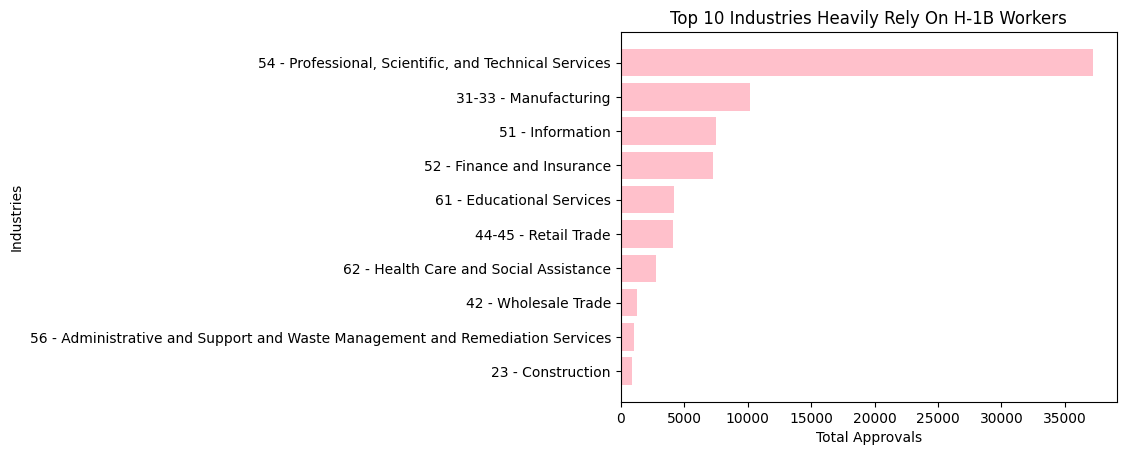

In [11]:
# Plot a horizontal bar chart of top 10 industries by Total Approvals
plt.barh(top10_industries.index, top10_industries.values, color="pink")

plt.xlabel('Total Approvals')
plt.ylabel('Industries')
plt.title('Top 10 Industries Heavily Rely On H-1B Workers')

plt.gca().invert_yaxis() 
plt.show()

In [12]:
# 2. “Which regions in the U.S. have the highest demand for H-1B workers?”
top10_regions = df_2026.groupby(['Petitioner State', 'Petitioner City'])['Total Approvals'].sum().sort_values(ascending=False).head(10)
top10_regions

Petitioner State  Petitioner City
NY                NEW YORK           4834.0
VA                ARLINGTON          2840.0
IL                CHICAGO            2829.0
CA                SAN FRANCISCO      2088.0
                  SAN JOSE           1795.0
                  SANTA CLARA        1786.0
MD                ROCKVILLE          1686.0
TX                AUSTIN             1610.0
CA                MOUNTAIN VIEW      1503.0
MA                BOSTON             1489.0
Name: Total Approvals, dtype: float64

In [13]:
top10_df = top10_regions.reset_index()
top10_df

,Petitioner State,Petitioner City,Total Approvals
0,NY,NEW YORK,4834.0
1,VA,ARLINGTON,2840.0
2,IL,CHICAGO,2829.0
3,CA,SAN FRANCISCO,2088.0
4,CA,SAN JOSE,1795.0
5,CA,SANTA CLARA,1786.0
6,MD,ROCKVILLE,1686.0
7,TX,AUSTIN,1610.0
8,CA,MOUNTAIN VIEW,1503.0
9,MA,BOSTON,1489.0


In [14]:
# Add a column named Location = State + City
top10_df["Location"] = top10_df["Petitioner State"] + " - " + top10_df["Petitioner City"]
top10_df

,Petitioner State,Petitioner City,Total Approvals,Location
0,NY,NEW YORK,4834.0,NY - NEW YORK
1,VA,ARLINGTON,2840.0,VA - ARLINGTON
2,IL,CHICAGO,2829.0,IL - CHICAGO
3,CA,SAN FRANCISCO,2088.0,CA - SAN FRANCISCO
4,CA,SAN JOSE,1795.0,CA - SAN JOSE
5,CA,SANTA CLARA,1786.0,CA - SANTA CLARA
6,MD,ROCKVILLE,1686.0,MD - ROCKVILLE
7,TX,AUSTIN,1610.0,TX - AUSTIN
8,CA,MOUNTAIN VIEW,1503.0,CA - MOUNTAIN VIEW
9,MA,BOSTON,1489.0,MA - BOSTON


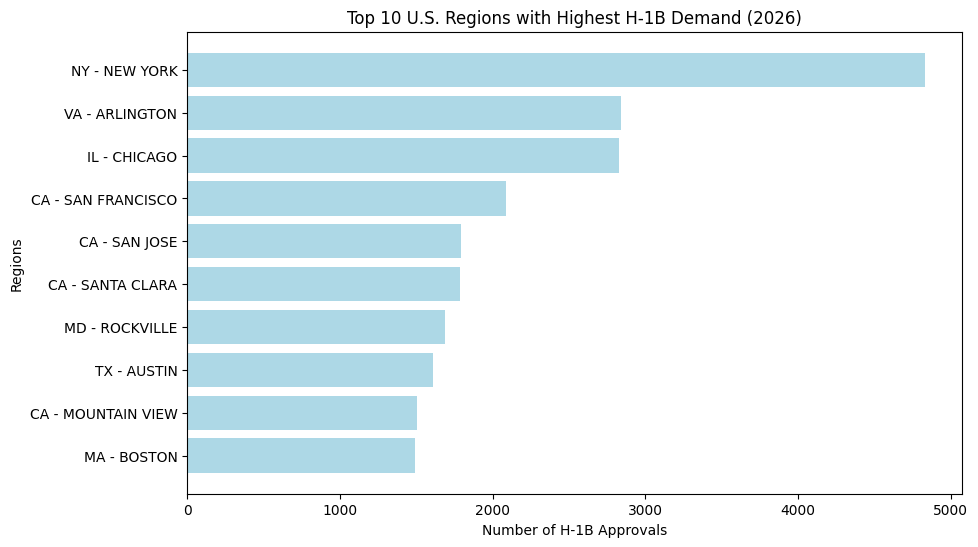

In [15]:
# Plot Q2
plt.figure(figsize=(10,6))
plt.barh(top10_df["Location"], top10_df["Total Approvals"], color="lightblue")

plt.xlabel("Number of H-1B Approvals")
plt.ylabel('Regions')
plt.title("Top 10 U.S. Regions with Highest H-1B Demand (2026)")

plt.gca().invert_yaxis()  # highest on top
plt.show()

In [16]:
# 3. “Which companies sponsor the most H-1B workers?”
top10_companies = df_2026.groupby('Employer (Petitioner) Name')['Total Approvals'].sum().sort_values(ascending=False).head(10)
top10_companies

Employer (Petitioner) Name
AMAZON COM SERVICES LLC                   2008.0
TATA CONSULTANCY SERVICES LIMITED         1518.0
MICROSOFT CORPORATION                     1179.0
INFOSYS LIMITED                           1139.0
GOOGLE LLC                                1040.0
APPLE INC                                  983.0
COGNIZANT TECHNOLOGY SOLUTIONS US CORP     980.0
META PLATFORMS INC                         698.0
TESLA INC                                  635.0
WAL-MART ASSOCIATES INC                    629.0
Name: Total Approvals, dtype: float64

In [17]:
top10_companies_df = top10_companies.reset_index()
top10_companies_df

,Employer (Petitioner) Name,Total Approvals
0,AMAZON COM SERVICES LLC,2008.0
1,TATA CONSULTANCY SERVICES LIMITED,1518.0
2,MICROSOFT CORPORATION,1179.0
3,INFOSYS LIMITED,1139.0
4,GOOGLE LLC,1040.0
5,APPLE INC,983.0
6,COGNIZANT TECHNOLOGY SOLUTIONS US CORP,980.0
7,META PLATFORMS INC,698.0
8,TESLA INC,635.0
9,WAL-MART ASSOCIATES INC,629.0


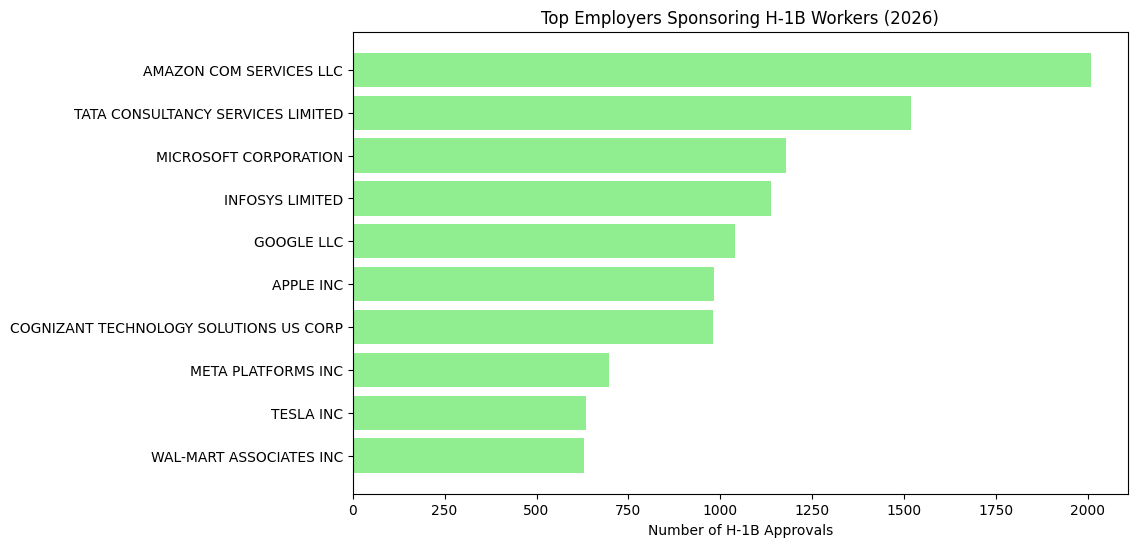

In [18]:
# Plot Q3
plt.figure(figsize=(10,6))
plt.barh(top10_companies_df["Employer (Petitioner) Name"], top10_companies_df["Total Approvals"], color='lightgreen')

plt.xlabel("Number of H-1B Approvals")
plt.title("Top Employers Sponsoring H-1B Workers (2026)")

plt.gca().invert_yaxis()
plt.show()

In [19]:
# extra: Top 10 Employers
df_2026.groupby( ['Industry (NAICS) Code', 'Employer (Petitioner) Name'] ).size()

Industry (NAICS) Code                            Employer (Petitioner) Name                     
11 - Agriculture, Forestry, Fishing and Hunting  BEL-AIRE FARM LLC                                  1
                                                 BEMAK N V LTD D B A ASHFORD STUD                   1
                                                 BUD ANTLE LLC                                      1
                                                 BYTESPEED LLC                                      1
                                                 CENTRAL CALIFORNIA ALMOND GROWERS ASSOCIATION      1
                                                                                                   ..
92 - Public Administration                       VERITY CREDIT UNION                                1
                                                 VILLAGE OF MATTESON                                1
                                                 WALTER KIDDE PORTABLE EQUIPMENT LLC   

In [20]:
df_2026['Industry (NAICS) Code'].unique() 
#use df_2026['Industry (NAICS) Code'].nunique() -> 20

array(['31-33 - Manufacturing', '72 - Accommodation and Food Services',
       '54 - Professional, Scientific, and Technical Services',
       '44-45 - Retail Trade', '51 - Information',
       '61 - Educational Services',
       '56 - Administrative and Support and Waste Management and Remediation Services',
       '42 - Wholesale Trade', '52 - Finance and Insurance', nan,
       '62 - Health Care and Social Assistance', '22 - Utilities',
       '71 - Arts, Entertainment, and Recreation',
       '55 - Management of Companies and Enterprises',
       '53 - Real Estate and Rental and Leasing', '23 - Construction',
       '81 - Other Services (except Public Administration)',
       '48-49 - Transportation and Warehousing',
       '92 - Public Administration',
       '21 - Mining, Quarrying, and Oil and Gas Extraction',
       '11 - Agriculture, Forestry, Fishing and Hunting'], dtype=object)

In [21]:
# I want to drop all the numbers in the Industry column
# Keep the industry name ONLY
df_2026["Industry (NAICS) Code"] = df_2026["Industry (NAICS) Code"].str.split(" - ").str[1]
df_2026

,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial,Total Approvals
0,NaN,Manufacturing,RANDOLPH,MA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,NaN,Manufacturing,HILLSBOROUGH,NH,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1 EMC LLC,Accommodation and Food Services,FINDLAY,OH,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1 NET SOFTWARE TECHNOLOGIES,"Professional, Scientific, and Technical Services",IRVING,TX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1-800-FLOWERS COM INC,Retail Trade,JERICHO,NY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24357,ZYNGA INC,Information,SAN MATEO,CA,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0
24358,ZYON DIGITAL SOLUTIONS LLC,"Professional, Scientific, and Technical Services",PLANO,TX,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24359,ZYPHRA TECHNOLOGIES INC.,"Professional, Scientific, and Technical Services",SAN FRANCISCO,CA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0
24360,ZYTER INC,"Professional, Scientific, and Technical Services",ROCKVILLE,MD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [22]:
# Check the column "Industry" again
df_2026['Industry (NAICS) Code'].unique() # OK!

array(['Manufacturing', 'Accommodation and Food Services',
       'Professional, Scientific, and Technical Services', 'Retail Trade',
       'Information', 'Educational Services',
       'Administrative and Support and Waste Management and Remediation Services',
       'Wholesale Trade', 'Finance and Insurance', nan,
       'Health Care and Social Assistance', 'Utilities',
       'Arts, Entertainment, and Recreation',
       'Management of Companies and Enterprises',
       'Real Estate and Rental and Leasing', 'Construction',
       'Other Services (except Public Administration)',
       'Transportation and Warehousing', 'Public Administration',
       'Mining, Quarrying, and Oil and Gas Extraction',
       'Agriculture, Forestry, Fishing and Hunting'], dtype=object)

In [23]:
df_2026

,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial,Total Approvals
0,NaN,Manufacturing,RANDOLPH,MA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,NaN,Manufacturing,HILLSBOROUGH,NH,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1 EMC LLC,Accommodation and Food Services,FINDLAY,OH,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1 NET SOFTWARE TECHNOLOGIES,"Professional, Scientific, and Technical Services",IRVING,TX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1-800-FLOWERS COM INC,Retail Trade,JERICHO,NY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24357,ZYNGA INC,Information,SAN MATEO,CA,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0
24358,ZYON DIGITAL SOLUTIONS LLC,"Professional, Scientific, and Technical Services",PLANO,TX,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24359,ZYPHRA TECHNOLOGIES INC.,"Professional, Scientific, and Technical Services",SAN FRANCISCO,CA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0
24360,ZYTER INC,"Professional, Scientific, and Technical Services",ROCKVILLE,MD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [24]:
# Now, I wanted to see top employers by industry
top_employers_by_industry = df_2026.groupby( ['Industry (NAICS) Code', 'Employer (Petitioner) Name'] )['Total Approvals'].sum().sort_values(ascending=False).head(10)
top_employers_by_industry = top_employers_by_industry.reset_index()
top_employers_by_industry

,Industry (NAICS) Code,Employer (Petitioner) Name,Total Approvals
0,Retail Trade,AMAZON COM SERVICES LLC,1958.0
1,"Professional, Scientific, and Technical Services",TATA CONSULTANCY SERVICES LIMITED,1490.0
2,Information,MICROSOFT CORPORATION,1174.0
3,"Professional, Scientific, and Technical Services",INFOSYS LIMITED,1136.0
4,"Professional, Scientific, and Technical Services",GOOGLE LLC,1027.0
5,Manufacturing,APPLE INC,982.0
6,"Professional, Scientific, and Technical Services",COGNIZANT TECHNOLOGY SOLUTIONS US CORP,881.0
7,Information,META PLATFORMS INC,692.0
8,Retail Trade,WAL-MART ASSOCIATES INC,628.0
9,Manufacturing,TESLA INC,625.0


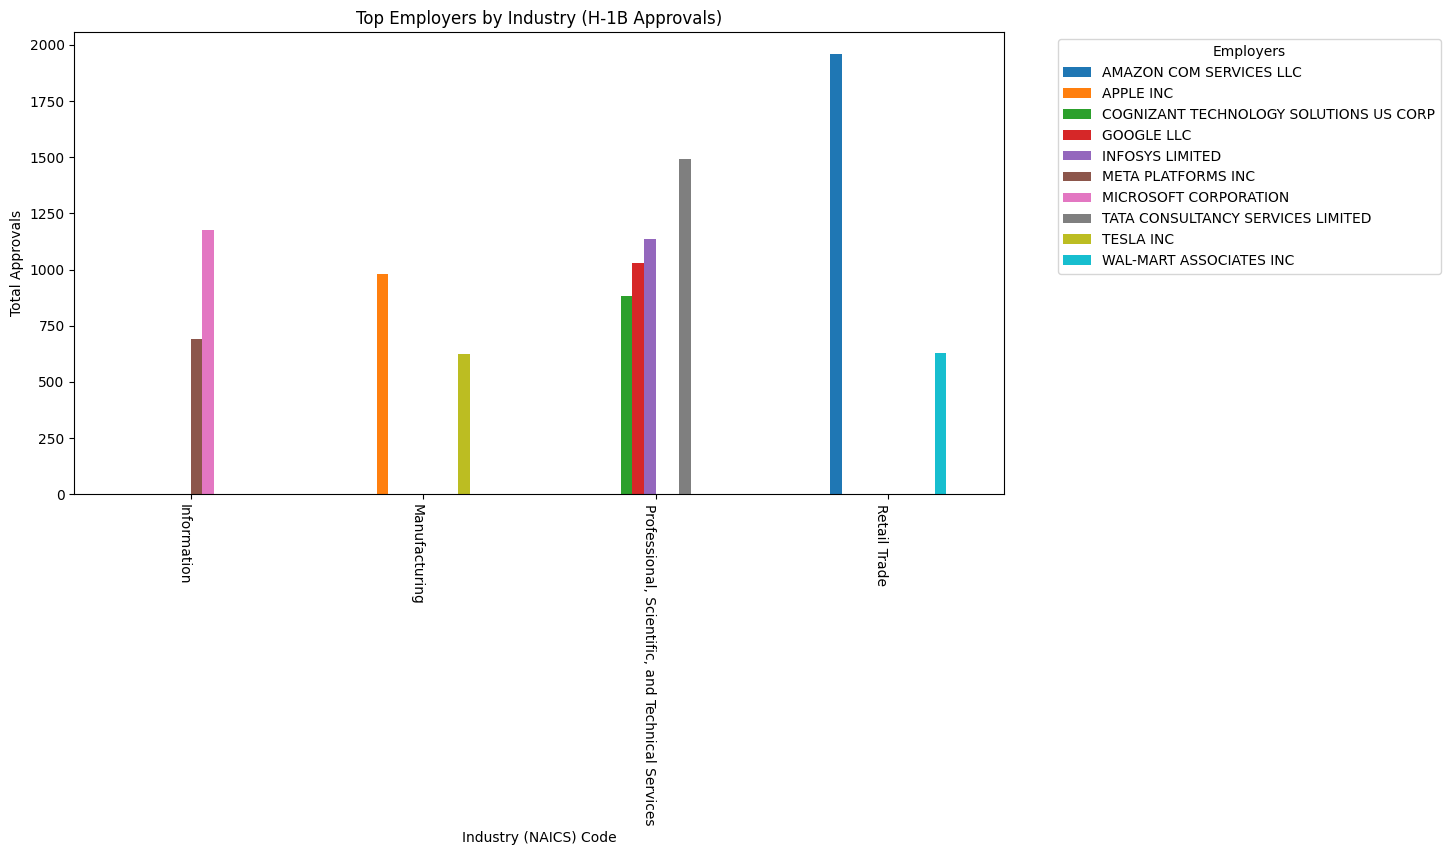

In [25]:
pivot = top_employers_by_industry.pivot(index="Industry (NAICS) Code",
                  columns="Employer (Petitioner) Name",
                  values="Total Approvals")

pivot.plot(kind="bar", figsize=(12,6))

plt.title("Top Employers by Industry (H-1B Approvals)")
plt.ylabel("Total Approvals")
plt.xticks(rotation=270, ha="right")

plt.legend(title="Employers", bbox_to_anchor=(1.05, 1))
plt.show()

Spring Break Work: LOGISTIC REGRESSION TEAM

Predict: H\-1B Approval \(Approved vs Denied\)

In [26]:
df_2026

,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial,Total Approvals
0,NaN,Manufacturing,RANDOLPH,MA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,NaN,Manufacturing,HILLSBOROUGH,NH,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1 EMC LLC,Accommodation and Food Services,FINDLAY,OH,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1 NET SOFTWARE TECHNOLOGIES,"Professional, Scientific, and Technical Services",IRVING,TX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,1-800-FLOWERS COM INC,Retail Trade,JERICHO,NY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24357,ZYNGA INC,Information,SAN MATEO,CA,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0
24358,ZYON DIGITAL SOLUTIONS LLC,"Professional, Scientific, and Technical Services",PLANO,TX,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24359,ZYPHRA TECHNOLOGIES INC.,"Professional, Scientific, and Technical Services",SAN FRANCISCO,CA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0
24360,ZYTER INC,"Professional, Scientific, and Technical Services",ROCKVILLE,MD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [27]:
denial_cols = ["New Employment Denial", "Continuation Denial", "Change with Same Employer Denial", 
"New Concurrent Denial", "Change of Employer Denial", "Amended Denial"]

df_2026["Total Denials"] = df_2026[denial_cols].sum(axis=1)
df_2026

,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial,Total Approvals,Total Denials
0,NaN,Manufacturing,RANDOLPH,MA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,NaN,Manufacturing,HILLSBOROUGH,NH,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1 EMC LLC,Accommodation and Food Services,FINDLAY,OH,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1 NET SOFTWARE TECHNOLOGIES,"Professional, Scientific, and Technical Services",IRVING,TX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1-800-FLOWERS COM INC,Retail Trade,JERICHO,NY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24357,ZYNGA INC,Information,SAN MATEO,CA,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0,1.0
24358,ZYON DIGITAL SOLUTIONS LLC,"Professional, Scientific, and Technical Services",PLANO,TX,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24359,ZYPHRA TECHNOLOGIES INC.,"Professional, Scientific, and Technical Services",SAN FRANCISCO,CA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0
24360,ZYTER INC,"Professional, Scientific, and Technical Services",ROCKVILLE,MD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [28]:
# Keep relevant variables/columns
df_2026_clean = df_2026[ ['Employer (Petitioner) Name',
                        'Industry (NAICS) Code',
                        'Petitioner City',
                        'Petitioner State',
                        'Total Approvals',
                        'Total Denials'] ]
df_2026_clean

,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,Total Approvals,Total Denials
0,NaN,Manufacturing,RANDOLPH,MA,1.0,0.0
1,NaN,Manufacturing,HILLSBOROUGH,NH,1.0,0.0
2,1 EMC LLC,Accommodation and Food Services,FINDLAY,OH,1.0,0.0
3,1 NET SOFTWARE TECHNOLOGIES,"Professional, Scientific, and Technical Services",IRVING,TX,1.0,0.0
4,1-800-FLOWERS COM INC,Retail Trade,JERICHO,NY,1.0,0.0
...,...,...,...,...,...,...
24357,ZYNGA INC,Information,SAN MATEO,CA,5.0,1.0
24358,ZYON DIGITAL SOLUTIONS LLC,"Professional, Scientific, and Technical Services",PLANO,TX,1.0,0.0
24359,ZYPHRA TECHNOLOGIES INC.,"Professional, Scientific, and Technical Services",SAN FRANCISCO,CA,3.0,0.0
24360,ZYTER INC,"Professional, Scientific, and Technical Services",ROCKVILLE,MD,1.0,0.0


In [29]:
# LOGISTIC REGRESSION MODEL
# Check dataset:
df_2026_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24362 entries, 0 to 24361
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employer (Petitioner) Name  24360 non-null  object 
 1   Industry (NAICS) Code       23515 non-null  object 
 2   Petitioner City             24362 non-null  object 
 3   Petitioner State            24356 non-null  object 
 4   Total Approvals             24362 non-null  float64
 5   Total Denials               24362 non-null  float64
dtypes: float64(2), object(4)
memory usage: 1.1+ MB


In [30]:
df_2026_clean["Approval Rate"] = df_2026_clean["Total Approvals"] / (
    df_2026_clean["Total Approvals"] + df_2026_clean["Total Denials"]
)
# Then, convert to binary for model
df_2026_clean["Approved Binary"] = (df_2026_clean["Approval Rate"] > 0.5).astype(int)

df_2026_clean

/tmp/ipykernel_51/3358704617.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2026_clean["Approval Rate"] = df_2026_clean["Total Approvals"] / (
/tmp/ipykernel_51/3358704617.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2026_clean["Approved Binary"] = (df_2026_clean["Approval Rate"] > 0.5).astype(int)


,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,Total Approvals,Total Denials,Approval Rate,Approved Binary
0,NaN,Manufacturing,RANDOLPH,MA,1.0,0.0,1.000000,1
1,NaN,Manufacturing,HILLSBOROUGH,NH,1.0,0.0,1.000000,1
2,1 EMC LLC,Accommodation and Food Services,FINDLAY,OH,1.0,0.0,1.000000,1
3,1 NET SOFTWARE TECHNOLOGIES,"Professional, Scientific, and Technical Services",IRVING,TX,1.0,0.0,1.000000,1
4,1-800-FLOWERS COM INC,Retail Trade,JERICHO,NY,1.0,0.0,1.000000,1
...,...,...,...,...,...,...,...,...
24357,ZYNGA INC,Information,SAN MATEO,CA,5.0,1.0,0.833333,1
24358,ZYON DIGITAL SOLUTIONS LLC,"Professional, Scientific, and Technical Services",PLANO,TX,1.0,0.0,1.000000,1
24359,ZYPHRA TECHNOLOGIES INC.,"Professional, Scientific, and Technical Services",SAN FRANCISCO,CA,3.0,0.0,1.000000,1
24360,ZYTER INC,"Professional, Scientific, and Technical Services",ROCKVILLE,MD,1.0,0.0,1.000000,1


1 = mostly approved, 0 = mostly denied

In [31]:
# Limit TOP 20 employers
top_employers = df_2026_clean["Employer (Petitioner) Name"].value_counts().head(20).index

df_2026_clean["Employer"] = df_2026_clean["Employer (Petitioner) Name"].where(
    df_2026_clean["Employer (Petitioner) Name"].isin(top_employers),
    "Other"
)
df_2026_clean

/tmp/ipykernel_51/3835974406.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2026_clean["Employer"] = df_2026_clean["Employer (Petitioner) Name"].where(


,Employer (Petitioner) Name,Industry (NAICS) Code,Petitioner City,Petitioner State,Total Approvals,Total Denials,Approval Rate,Approved Binary,Employer
0,NaN,Manufacturing,RANDOLPH,MA,1.0,0.0,1.000000,1,Other
1,NaN,Manufacturing,HILLSBOROUGH,NH,1.0,0.0,1.000000,1,Other
2,1 EMC LLC,Accommodation and Food Services,FINDLAY,OH,1.0,0.0,1.000000,1,Other
3,1 NET SOFTWARE TECHNOLOGIES,"Professional, Scientific, and Technical Services",IRVING,TX,1.0,0.0,1.000000,1,Other
4,1-800-FLOWERS COM INC,Retail Trade,JERICHO,NY,1.0,0.0,1.000000,1,Other
...,...,...,...,...,...,...,...,...,...
24357,ZYNGA INC,Information,SAN MATEO,CA,5.0,1.0,0.833333,1,Other
24358,ZYON DIGITAL SOLUTIONS LLC,"Professional, Scientific, and Technical Services",PLANO,TX,1.0,0.0,1.000000,1,Other
24359,ZYPHRA TECHNOLOGIES INC.,"Professional, Scientific, and Technical Services",SAN FRANCISCO,CA,3.0,0.0,1.000000,1,Other
24360,ZYTER INC,"Professional, Scientific, and Technical Services",ROCKVILLE,MD,1.0,0.0,1.000000,1,Other


In [32]:
# Chosen Features
features = ["Employer", "Industry (NAICS) Code", "Petitioner State"]

X = pd.get_dummies(df_2026_clean[features], drop_first=True)
y = df_2026_clean["Approved Binary"]

In [33]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [53]:
# Train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [55]:
weights = df_2026_clean["Total Approvals"] + df_2026_clean["Total Denials"]

model.fit(X_train, y_train, sample_weight=weights.loc[X_train.index])

LogisticRegression(class_weight='balanced', max_iter=1000)

In [57]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

importance.head(15)

,Feature,Coefficient
30,"Industry (NAICS) Code_Mining, Quarrying, and O...",3.086581
28,Industry (NAICS) Code_Management of Companies ...,2.363989
18,Employer_WIPRO LIMITED,2.224123
50,Petitioner State_GU,2.197689
92,Petitioner State_WV,2.087171
21,"Industry (NAICS) Code_Agriculture, Forestry, F...",2.028659
27,Industry (NAICS) Code_Information,1.975823
61,Petitioner State_ME,1.929306
25,Industry (NAICS) Code_Finance and Insurance,1.741686
29,Industry (NAICS) Code_Manufacturing,1.665546


In [59]:
top_positive = importance.sort_values("Coefficient", ascending=False).head(10)
top_negative = importance.sort_values("Coefficient", ascending=True).head(10)

print("Top positive predictors:")
print(top_positive)

print("\nTop negative predictors:")
print(top_negative)

Top positive predictors:
                                              Feature  Coefficient
30  Industry (NAICS) Code_Mining, Quarrying, and O...     3.086581
28  Industry (NAICS) Code_Management of Companies ...     2.363989
18                             Employer_WIPRO LIMITED     2.224123
50                                Petitioner State_GU     2.197689
92                                Petitioner State_WV     2.087171
21  Industry (NAICS) Code_Agriculture, Forestry, F...     2.028659
27                  Industry (NAICS) Code_Information     1.975823
61                                Petitioner State_ME     1.929306
25        Industry (NAICS) Code_Finance and Insurance     1.741686
29                Industry (NAICS) Code_Manufacturing     1.665546

Top negative predictors:
                                             Feature  Coefficient
10                  Employer_THE DEVEREUX FOUNDATION    -5.694415
93                               Petitioner State_WY    -4.148921
13            

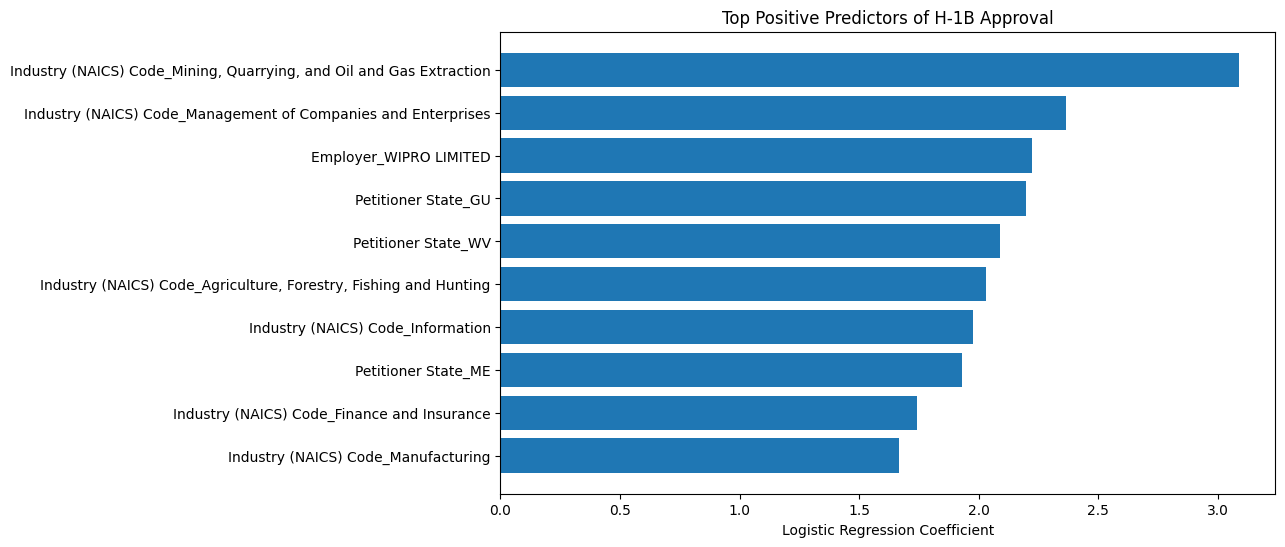

In [60]:
top10 = importance.sort_values("Coefficient", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Coefficient"])
plt.title("Top Positive Predictors of H-1B Approval")
plt.xlabel("Logistic Regression Coefficient")

plt.gca().invert_yaxis()
plt.show()

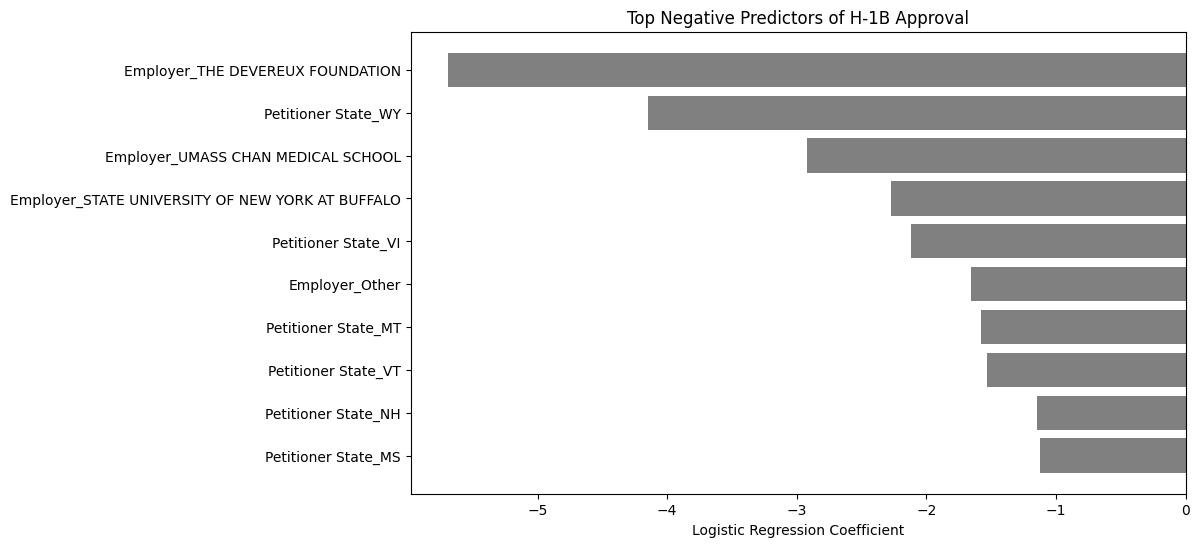

In [61]:
bottom10 = importance.sort_values("Coefficient", ascending=True).head(10)

plt.figure(figsize=(10,6))
plt.barh(bottom10["Feature"], bottom10["Coefficient"], color='grey')
plt.title("Top Negative Predictors of H-1B Approval")
plt.xlabel("Logistic Regression Coefficient")

plt.gca().invert_yaxis()
plt.show()

# Evaluate the Current Model: Logistic Regression

In [62]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.gridspec as gridspec

In [63]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1 (Approved)

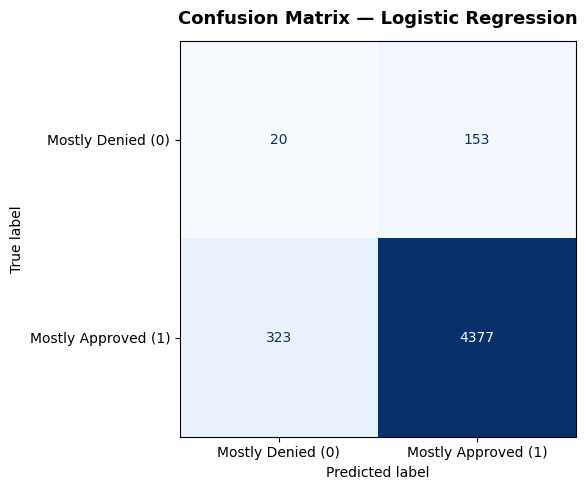

In [65]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
 
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Mostly Denied (0)", "Mostly Approved (1)"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Logistic Regression", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

1\. Top\-left  = True Negatives  \(correctly predicted Denied\)

2\. Top\-right = False Positives \(predicted Approved, actually Denied\)

3\. Bot\-left  = False Negatives \(predicted Denied, actually Approved\)

4\. Bot\-right = True Positives  \(correctly predicted Approved\)

In [67]:
print("REPORT — Logistic Regression")
print(classification_report(y_test, y_pred,
                             target_names=["Mostly Denied", "Mostly Approved"]))

REPORT — Logistic Regression
                 precision    recall  f1-score   support

  Mostly Denied       0.06      0.12      0.08       173
Mostly Approved       0.97      0.93      0.95      4700

       accuracy                           0.90      4873
      macro avg       0.51      0.52      0.51      4873
   weighted avg       0.93      0.90      0.92      4873



In [68]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc       = roc_auc_score(y_test, y_prob)
 
print("  Classification Metrics")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")

  Classification Metrics
  Accuracy  : 0.9023
  Precision : 0.9662
  Recall    : 0.9313
  F1-Score  : 0.9484
  AUC-ROC   : 0.5321


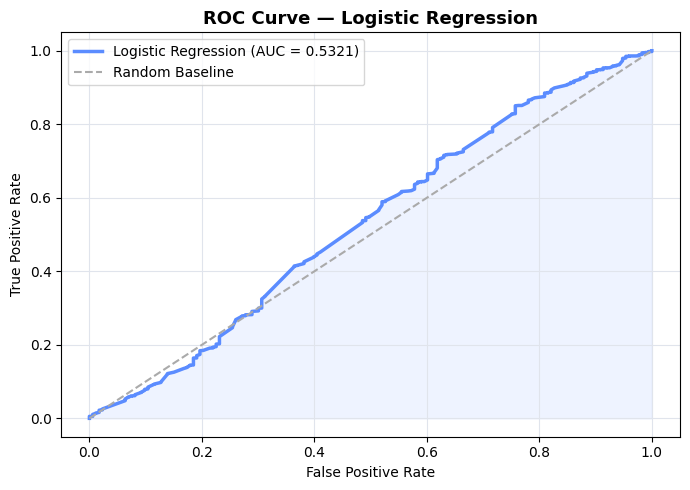

In [72]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
 
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#5B8CFF", lw=2.5, label=f"Logistic Regression (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="#AAAAAA", lw=1.5, label="Random Baseline")
plt.fill_between(fpr, tpr, alpha=0.10, color="#5B8CFF")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(color="#E0E4EC", linewidth=0.8)
plt.tight_layout()
plt.show()

## Random Forest

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [76]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [78]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

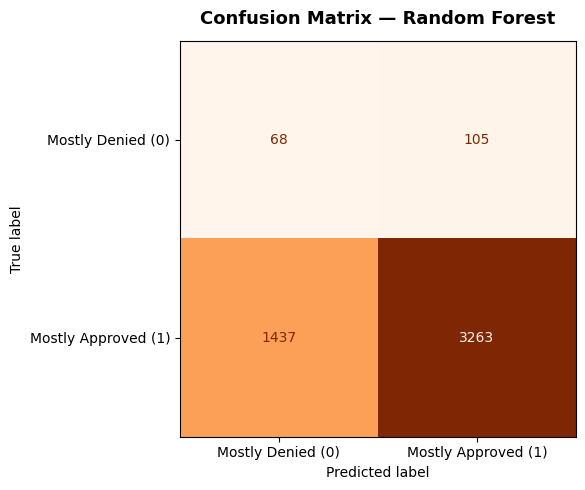

In [80]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
 
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                              display_labels=["Mostly Denied (0)", "Mostly Approved (1)"])
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("Confusion Matrix — Random Forest", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

In [82]:
print(classification_report(y_test, y_pred_rf,
                             target_names=["Mostly Denied", "Mostly Approved"]))

                 precision    recall  f1-score   support

  Mostly Denied       0.05      0.39      0.08       173
Mostly Approved       0.97      0.69      0.81      4700

       accuracy                           0.68      4873
      macro avg       0.51      0.54      0.44      4873
   weighted avg       0.94      0.68      0.78      4873



In [84]:
accuracy_rf  = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf    = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf        = f1_score(y_test, y_pred_rf, zero_division=0)
auc_rf       = roc_auc_score(y_test, y_prob_rf)
 
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"AUC-ROC   : {auc_rf:.4f}")

Accuracy  : 0.6836
Precision : 0.9688
Recall    : 0.6943
F1-Score  : 0.8089
AUC-ROC   : 0.5423


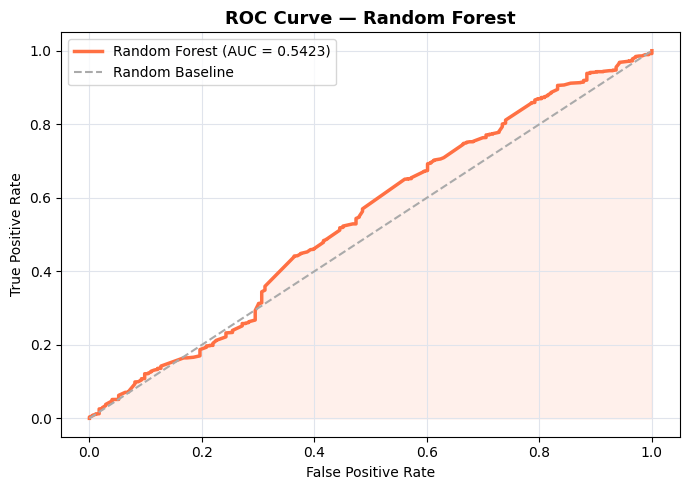

In [86]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
 
plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, color="#FF7043", lw=2.5, label=f"Random Forest (AUC = {auc_rf:.4f})")
plt.plot([0, 1], [0, 1], "--", color="#AAAAAA", lw=1.5, label="Random Baseline")
plt.fill_between(fpr_rf, tpr_rf, alpha=0.10, color="#FF7043")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(color="#E0E4EC", linewidth=0.8)
plt.tight_layout()
plt.show()

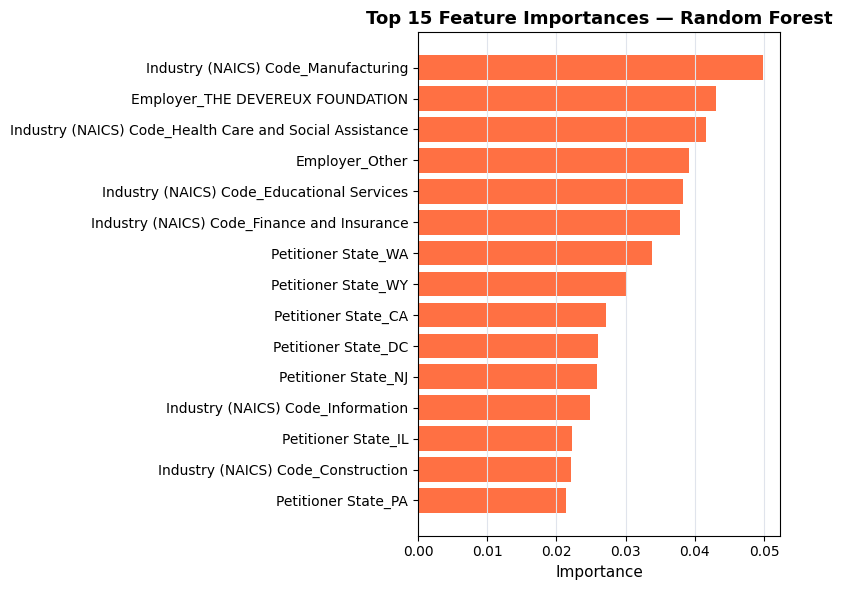

In [88]:
fi = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top15 = fi.sort_values(ascending=True).tail(15)
 
plt.figure(figsize=(8, 6))
plt.barh(top15.index, top15.values, color="#FF7043")
plt.xlabel("Importance", fontsize=11)
plt.title("Top 15 Feature Importances — Random Forest", fontsize=13, fontweight="bold")
plt.grid(axis="x", color="#E0E4EC", linewidth=0.8)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=299a6352-7284-48f9-9b28-3661e9f11c40' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>